<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [10]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.1’

survey-results-publ 100%[===================>] 201.62M  7.80MB/s    in 35s     
2026-09-16 09:12:49 (5.81 MB/s) - ‘survey-results-public.sqlite.1’ saved [211415040/211415040]


#### 2. Connect to the Database


**Install the needed libraries**


In [11]:
!pip install pandas

In [13]:
!pip install matplotlib
!pip install numpy
!pip install seaborn

In [34]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [35]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437

#### Demo 2: List All Tables


In [16]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [15]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


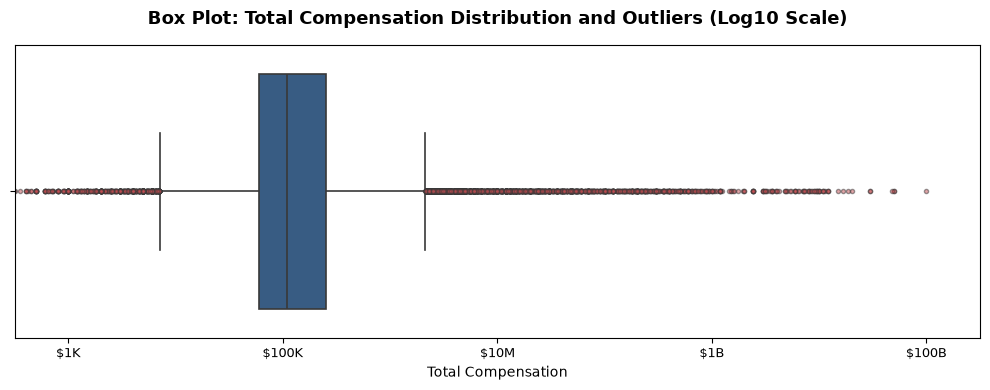

In [17]:
# your code goes here
# Query CompTotal from SQLite database
query = """
SELECT CompTotal 
FROM main 
WHERE CompTotal IS NOT NULL 
  AND CompTotal > 0
"""
df_comp = pd.read_sql_query(query, conn)

# Calculate explicit log10 values to handle wide salary ranges
df_comp["log_CompTotal"] = np.log10(df_comp["CompTotal"])

# Render Box Plot
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df_comp,
    x="log_CompTotal",
    color="#2b5c8f",
    fliersize=3,
    linewidth=1.2,
    flierprops={"markerfacecolor": "#c44e52", "alpha": 0.5},
)

# Hardcode x-ticks for log10 compensation scale
fixed_ticks = [3, 5, 7, 9, 11]
fixed_labels = ["$1K", "$100K", "$10M", "$1B", "$100B"]

plt.xticks(fixed_ticks, fixed_labels, fontsize=9)
plt.xlim(2.5, 11.5)

plt.title(
    "Box Plot: Total Compensation Distribution and Outliers (Log10 Scale)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Total Compensation", fontsize=10)

plt.tight_layout()
plt.show()


* Median (Q2): Sits right in the center of the box at$\approx 5.0$, which equals `$100K `
* First Quartile (Q1 - Left Edge of Box): Sits near 4.7 on the log scale approximately
  50K
* Third Quartile (Q3 - Right Edge of Box): Sits near $5.2$ or $5.3$ on the log scale approximately 160K - 200K
So the IQR (the middle 50% of respondents) spans from roughly `$50K` to `$200K`.

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


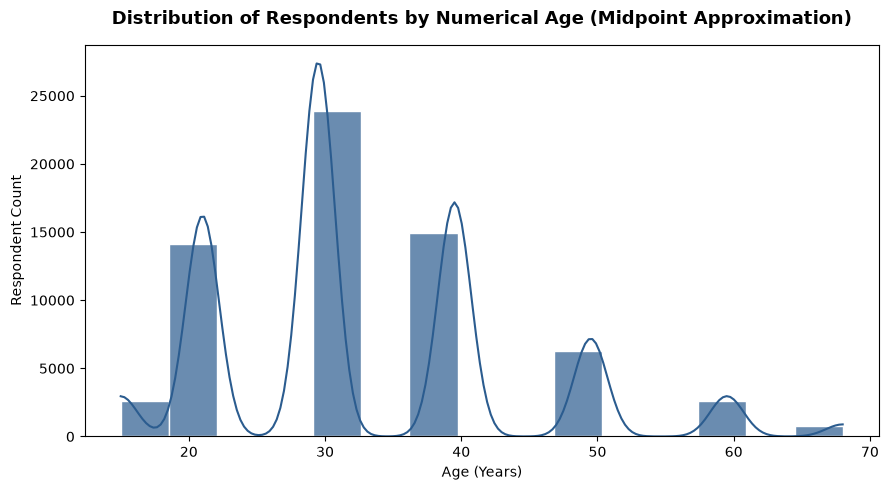

In [18]:
# your code goes here
# Query Age column from SQLite database
query = """
SELECT Age 
FROM main 
WHERE Age IS NOT NULL 
  AND Age != 'Prefer not to say'
"""
df_age = pd.read_sql_query(query, conn)

# Map age ranges to representative numerical midpoints
age_map = {
    "Under 18 years old": 15.0,
    "18-24 years old": 21.0,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 68.0,
}

df_age["Age_Numeric"] = df_age["Age"].map(age_map)

# Render Numerical Age Distribution
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_age,
    x="Age_Numeric",
    bins=15,
    color="#2b5c8f",
    edgecolor="white",
    alpha=0.7,
    kde=True,
)

plt.title(
    "Distribution of Respondents by Numerical Age (Midpoint Approximation)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Age (Years)", fontsize=10)
plt.ylabel("Respondent Count", fontsize=10)

plt.tight_layout()
plt.show()

We can see thath the main part of the respondents are part of the main workforse at the age of 35-45.

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


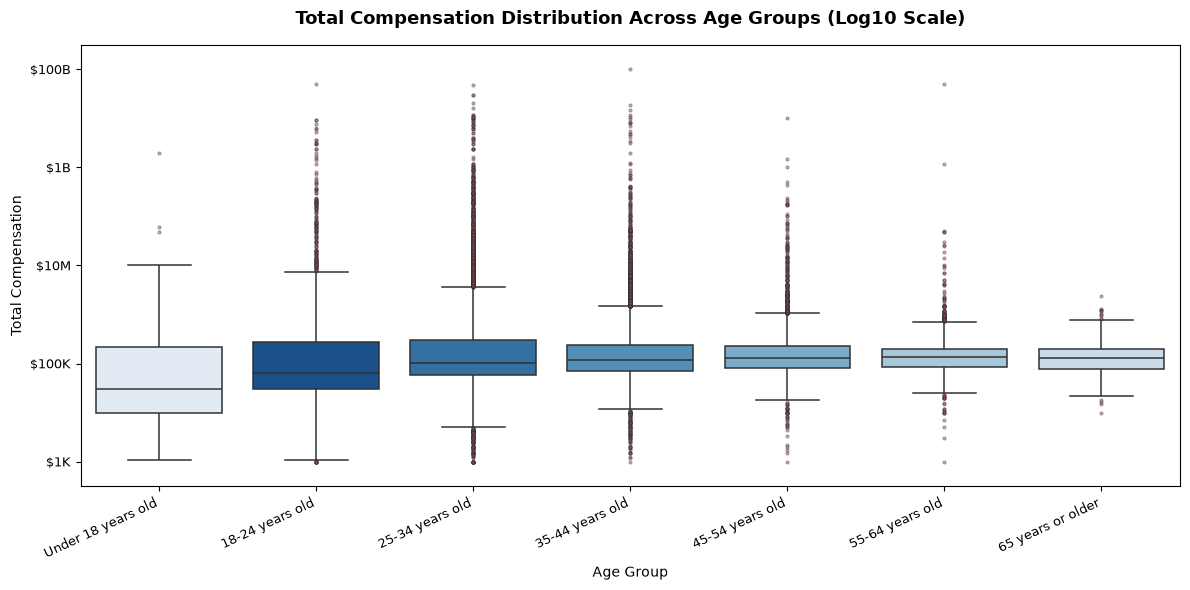

In [20]:
# your code goes here
# Query CompTotal and Age from SQLite database
query = """
SELECT CompTotal, Age 
FROM main 
WHERE CompTotal IS NOT NULL 
  AND CompTotal >= 1000 
  AND Age IS NOT NULL 
  AND Age != 'Prefer not to say'
"""
df_comp_age = pd.read_sql_query(query, conn)

# Calculate log10 transformed compensation
df_comp_age["log_CompTotal"] = np.log10(df_comp_age["CompTotal"])

# Set chronological category order for age brackets
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older",
]

# Render Comparative Boxplot of Compensation across Age Groups
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_comp_age,
    x="Age",
    y="log_CompTotal",
    order=age_order,
    hue="Age",
    legend=False,
    palette="Blues_r",
    fliersize=2,
    linewidth=1.1,
    flierprops={"markerfacecolor": "#c44e52", "alpha": 0.4},
)

# Hardcode y-ticks for log10 compensation scale
fixed_ticks = [3, 5, 7, 9, 11]
fixed_labels = ["$1K", "$100K", "$10M", "$1B", "$100B"]

plt.yticks(fixed_ticks, fixed_labels, fontsize=9)
plt.ylim(2.5, 11.5)

plt.xticks(rotation=25, ha="right", fontsize=9)
plt.title(
    "Total Compensation Distribution Across Age Groups (Log10 Scale)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Age Group", fontsize=10)
plt.ylabel("Total Compensation", fontsize=10)

plt.tight_layout()
plt.show()

We can see that the distributions follow a similar pattern with whiskers getting shorter in the upper age bracket.

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


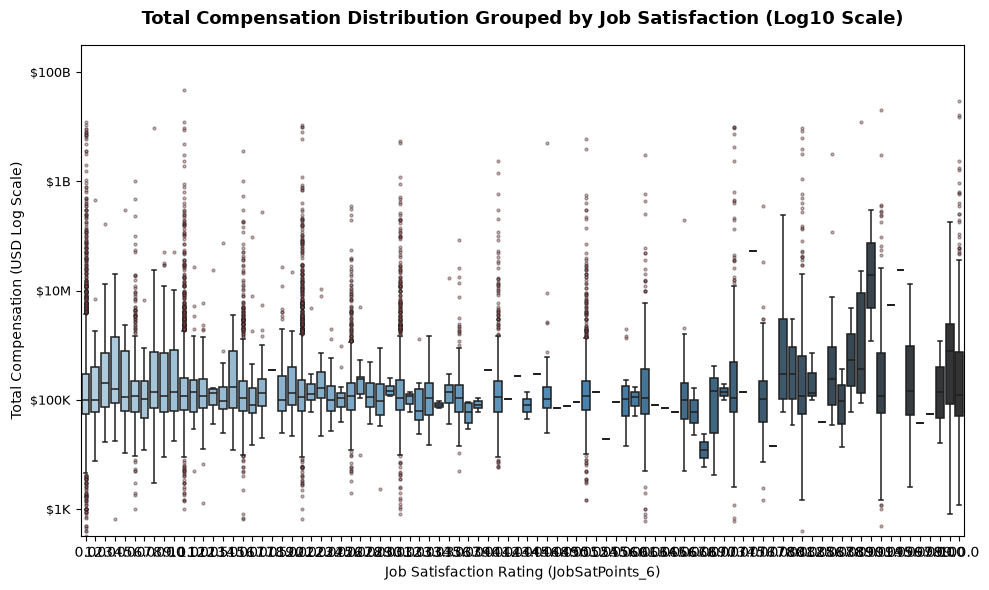

In [19]:
# Query CompTotal and JobSatPoints_6 from database
query = """
SELECT CompTotal, JobSatPoints_6 
FROM main 
WHERE CompTotal IS NOT NULL 
  AND CompTotal > 0 
  AND JobSatPoints_6 IS NOT NULL
"""
df_jobsat_comp = pd.read_sql_query(query, conn)

# Log-transform total compensation to manage wide distribution ranges
df_jobsat_comp["log_CompTotal"] = np.log10(df_jobsat_comp["CompTotal"])

# Ensure JobSatPoints_6 is treated as a sorted categorical rating
satisfaction_order = sorted(df_jobsat_comp["JobSatPoints_6"].unique())

# Render Box Plot of Compensation across Job Satisfaction Ratings
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_jobsat_comp,
    x="JobSatPoints_6",
    y="log_CompTotal",
    order=satisfaction_order,
    hue="JobSatPoints_6",
    legend=False,
    palette="Blues_d",
    fliersize=2,
    linewidth=1.1,
    flierprops={"markerfacecolor": "#c44e52", "alpha": 0.4},
)

# Set human-readable currency labels on the log10 y-axis
fixed_ticks = [3, 5, 7, 9, 11]
fixed_labels = ["$1K", "$100K", "$10M", "$1B", "$100B"]

plt.yticks(fixed_ticks, fixed_labels, fontsize=9)
plt.ylim(2.5, 11.5)

plt.title(
    "Total Compensation Distribution Grouped by Job Satisfaction (Log10 Scale)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Job Satisfaction Rating (JobSatPoints_6)", fontsize=10)
plt.ylabel("Total Compensation (USD Log Scale)", fontsize=10)

plt.tight_layout()
plt.show()

As we can see there is no real conection between jobsatisfaction and total compensation.

Due to JobSatPoint_6 being a continuous value in the range [0,100] and thus the plot being ovecrowded we define 5 satisfaction tiers.

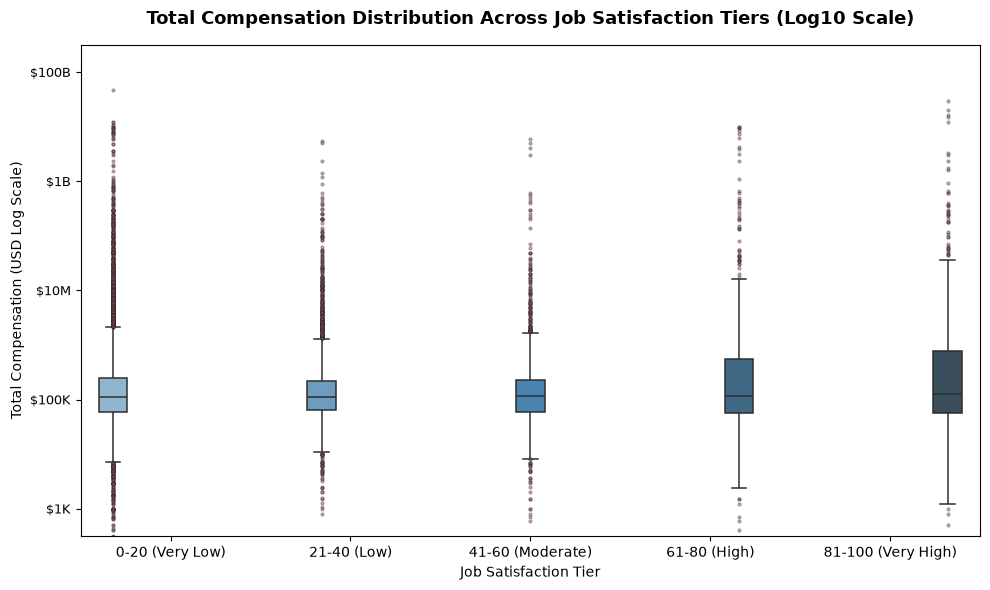

In [23]:
# Create readable 10-point or 20-point satisfaction tiers for clean visual scanning
df_jobsat_comp["Sat_Tier"] = pd.cut(
    df_jobsat_comp["JobSatPoints_6"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20 (Very Low)", "21-40 (Low)", "41-60 (Moderate)", "61-80 (High)", "81-100 (Very High)"],
    include_lowest=True
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_jobsat_comp,
    x="Sat_Tier",
    y="log_CompTotal",
    hue="Sat_Tier",
    legend=False,
    palette="Blues_d",
    fliersize=2,
    linewidth=1.1,
    flierprops={"markerfacecolor": "#c44e52", "alpha": 0.4},
)

fixed_ticks = [3, 5, 7, 9, 11]
fixed_labels = ["$1K", "$100K", "$10M", "$1B", "$100B"]

plt.yticks(fixed_ticks, fixed_labels, fontsize=9)
plt.ylim(2.5, 11.5)

plt.title(
    "Total Compensation Distribution Across Job Satisfaction Tiers (Log10 Scale)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Job Satisfaction Tier", fontsize=10)
plt.ylabel("Total Compensation (USD Log Scale)", fontsize=10)

plt.tight_layout()
plt.show()

Even grouped in satisfaction tiers we cannot observe a meaningful conection betwween the 2 values. Only that the box9hence the varience is bigger in respondents with high satisfaction scores but the whiskers are also bigger.

No Linear Correlation: Median compensation stays surprisingly flat across job satisfaction tiers, proving that high compensation alone does not guarantee higher job satisfaction (and vice versa).

Greater Variance at High Satisfaction: The wider interquartile ranges (IQR/boxes) and longer whiskers in high-satisfaction tiers show that highly satisfied developers come from a much broader spectrum of compensation levels—spanning everything from lower-paying passion projects and non-profits to high-earning senior enterprise roles.

Low-Satisfaction Compression: Respondents with lower satisfaction scores display tighter variance, suggesting their dissatisfaction is often tied to predictable, narrow compensation bands.

In [21]:
df_jobsat_comp["JobSatPoints_6"].unique()

array([ 65. ,   0. ,  20. ,  30. ,  25. ,  50. ,  10. ,   5. ,  15. ,
        18. ,  40. ,  35. ,  33. ,  80. , 100. ,   2. ,  90. ,  45. ,
        34. ,  16. ,  70. ,   7. ,  85. ,  60. ,   1. ,   9. ,  14. ,
        31. ,  12. ,  11. ,  23. ,  28. ,  75. ,   8. ,  81. ,   6. ,
        13. ,  55. ,   3. ,  22. ,  42. ,   4. ,  89. ,  99. ,  12.5,
        36. ,  27. ,  17. ,  95. ,  21. ,  24. ,  19. ,  87. ,  88. ,
        29. ,  33.3,  37. ,  39. ,  77. ,  68. ,  26. ,  32. ,  66. ,
        82. ,  94. ,  78. ,  61. ,  43. ,  69. ,  73. ,  17.5,  46. ,
        49. ,  52. ,  97. ,  96. ,  67. ,  91. ,  86. ,  56. ,  98. ,
        41. ,  74. ,  51. ,  76. ,  48. ,  44. ,  64. ,  54. ,  63. ])

In [29]:
# Summary statistics across satisfaction tiers
sat_stats = df_jobsat_comp.groupby("Sat_Tier")["CompTotal"].agg(
    Count="count",
    Median="median",
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
)

print("=== Job Satisfaction vs. Compensation Metrics ===")
print(sat_stats.round(2))

=== Job Satisfaction vs. Compensation Metrics ===
                    Count    Median       IQR
Sat_Tier                                     
0-20 (Very Low)     13867  110000.0  190000.0
21-40 (Low)          4582  113000.0  151000.0
41-60 (Moderate)     1515  115000.0  168000.0
61-80 (High)         1126  115000.0  501475.0
81-100 (Very High)   1348  128500.0  708600.0

| Satisfaction Tier | Respondent Count | Share of Total (%) | Median Pay (USD) | IQR Variance (USD) |
| --- | --- | --- | --- | --- |
| 0–20 (Very Low) | 13,867 | 61.8% | 110,000 | 190,000 |
| 21–40 (Low) | 4,582 | 20.4% | 113,000 | 151,000 |
| 41–60 (Moderate) | 1,515 | 6.8% | 115,000 | 168,000 |
| 61–80 (High) | 1,126 | 5.0% | 115,000 | 501,475 |
| 81–100 (Very High) | 1,348 | 6.0% | 128,500 | 708,600 |

Overwhelming Dissatisfaction Skew: Over 82% of respondents fall into the combined low-satisfaction buckets (0–40 score), showing widespread dissatisfaction across the developer ecosystem regardless of salary baseline.

Minimal Pay Difference (`$110K `vs. `$128.5K`): Despite a massive jump in satisfaction from 0–20 to 81–100, the median compensation only moves by `~$18.5K` (~16.8%). Money clearly isn't buying day-to-day job satisfaction here.

Exploding High-End Variance (IQR): The Interquartile Range explodes from $190,000 in the lowest tier to `$708,600` in the top tier. High satisfaction isn't locked to high pay, but developers with extreme compensation packages (or custom pay structures) drive immense spread at the top.

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


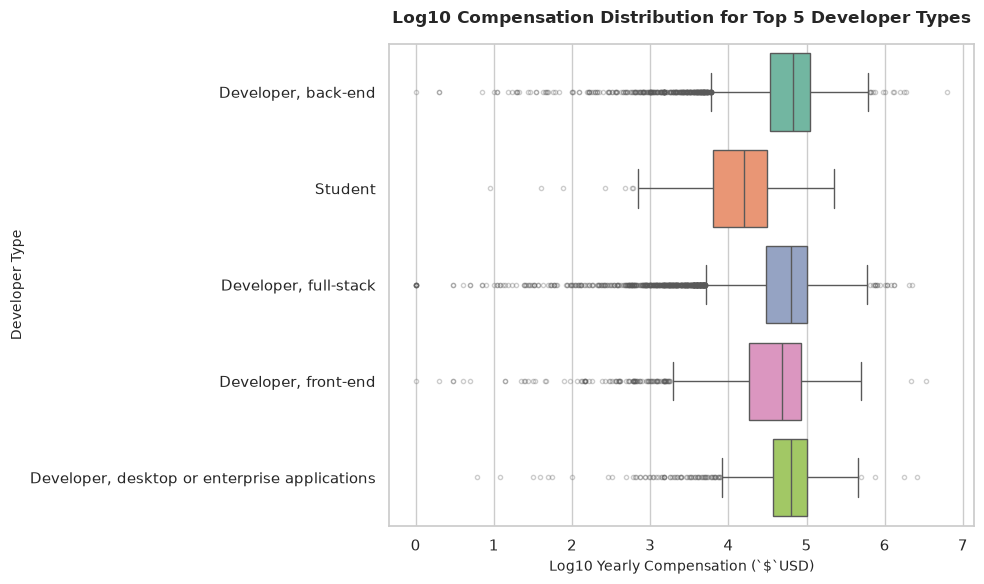

In [38]:
# Query top 5 developer types and positive yearly compensation
query = """
SELECT DevType, ConvertedCompYearly
FROM main
WHERE DevType IS NOT NULL 
  AND ConvertedCompYearly IS NOT NULL
  AND ConvertedCompYearly > 0
  AND DevType IN (
      SELECT DevType
      FROM main
      WHERE DevType IS NOT NULL
      GROUP BY DevType
      ORDER BY COUNT(*) DESC
      LIMIT 5
  )
"""
df_top5_devs = pd.read_sql_query(query, conn)

# Log10 transform compensation
df_top5_devs["Log_ConvertedCompYearly"] = np.log10(
    df_top5_devs["ConvertedCompYearly"]
)

# Configure plot layout
sns.set_theme(style="whitegrid", font="sans-serif")
plt.figure(figsize=(10, 6))

# Horizontal box plot using log10 scale
ax = sns.boxplot(
    data=df_top5_devs,
    x="Log_ConvertedCompYearly",
    y="DevType",
    hue="DevType",
    legend=False,
    palette="Set2",
    flierprops=dict(marker="o", color="red", alpha=0.3, markersize=3),
)

# Format titles and labels
plt.title(
    "Log10 Compensation Distribution for Top 5 Developer Types",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Log10 Yearly Compensation (`$`USD)", fontsize=10)
plt.ylabel("Developer Type", fontsize=10)

plt.tight_layout()
plt.show()

We can observe that the role is not a good predictor for compensation the only exception being Student.

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


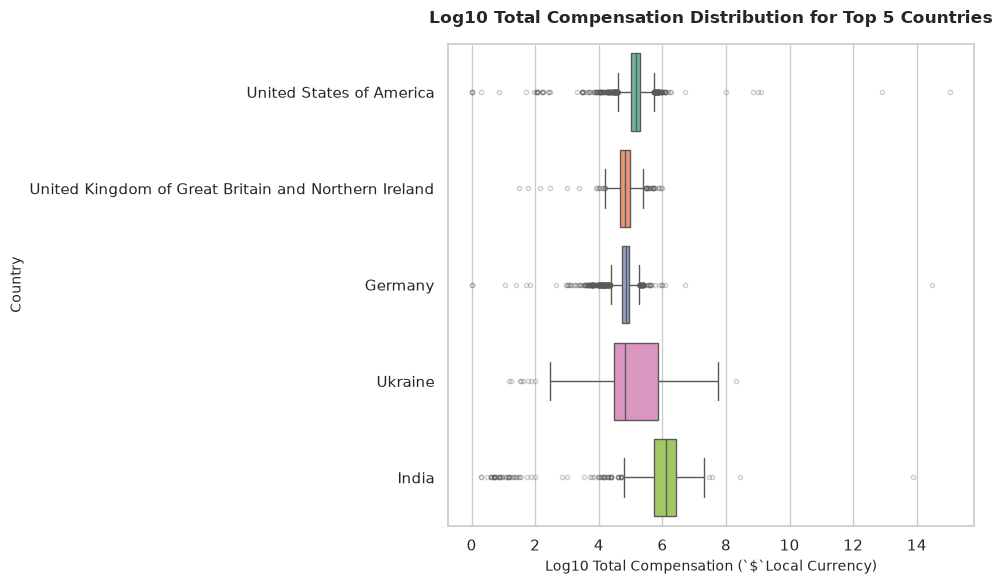

In [39]:
# your code goes here
# Query top 5 countries by respondent count and positive total compensation
query = """
SELECT Country, CompTotal
FROM main
WHERE Country IS NOT NULL 
  AND CompTotal IS NOT NULL
  AND CompTotal > 0
  AND Country IN (
      SELECT Country
      FROM main
      WHERE Country IS NOT NULL
      GROUP BY Country
      ORDER BY COUNT(*) DESC
      LIMIT 5
  )
"""
df_top5_countries = pd.read_sql_query(query, conn)

# Log10 transform total compensation
df_top5_countries["Log_CompTotal"] = np.log10(df_top5_countries["CompTotal"])

# Configure plot layout
sns.set_theme(style="whitegrid", font="sans-serif")
plt.figure(figsize=(10, 6))

# Horizontal box plot of log10 total compensation across top 5 countries
ax = sns.boxplot(
    data=df_top5_countries,
    x="Log_CompTotal",
    y="Country",
    hue="Country",
    legend=False,
    palette="Set2",
    flierprops=dict(marker="o", color="red", alpha=0.3, markersize=3),
)

# Format titles and labels
plt.title(
    "Log10 Total Compensation Distribution for Top 5 Countries",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Log10 Total Compensation (`$`Local Currency)", fontsize=10)
plt.ylabel("Country", fontsize=10)

plt.tight_layout()
plt.show()

Median local compensation remains relatively consistent across the United States, Germany, the United Kingdom, and Ukraine, whereas India exhibits a significantly higher median value on the local currency scale.

The boxplot distributions reveal key structural differences across regions:

* United States, United Kingdom, and Germany: Display highly compact interquartile ranges (IQRs), indicating tight clustering around national pay benchmarks. The United States stands out with prominent upper-bound outliers extending far beyond the upper whisker.

* Ukraine: Shows a noticeably broader spread across its IQR, reflecting wider variance in reported local currency compensation.

* India: Features a compact boxplot distribution centered at a substantially higher magnitude due to local currency denomination values.

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


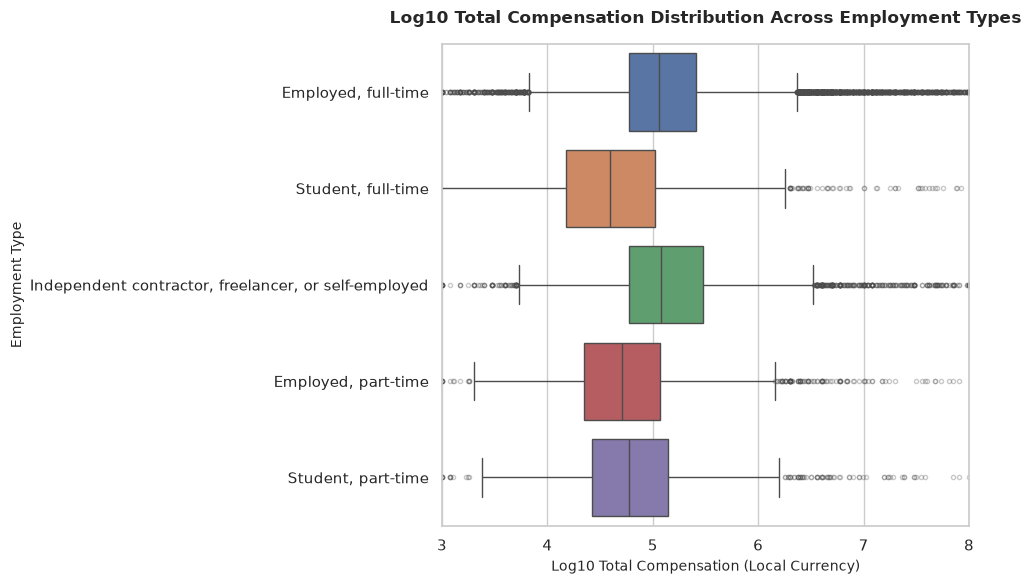

In [43]:
# Query Employment and CompTotal
query = """
SELECT Employment, CompTotal
FROM main
WHERE Employment IS NOT NULL 
  AND CompTotal IS NOT NULL
  AND CompTotal > 0
"""
df_emp = pd.read_sql_query(query, conn)

# Explode multi-select employment responses
df_emp_exploded = df_emp.assign(
    Employment=df_emp["Employment"].str.split(";")
).explode("Employment")
df_emp_exploded["Employment"] = df_emp_exploded["Employment"].str.strip()

# Keep top employment categories to clean up visualization
top_emp_types = df_emp_exploded["Employment"].value_counts().head(5).index
df_emp_filtered = df_emp_exploded[
    df_emp_exploded["Employment"].isin(top_emp_types)
].copy()

# Log10 transform total compensation
df_emp_filtered["Log_CompTotal"] = np.log10(df_emp_filtered["CompTotal"])

plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=df_emp_filtered,
    x="Log_CompTotal",
    y="Employment",
    hue="Employment",
    legend=False,
    flierprops=dict(marker="o", color="red", alpha=0.3, markersize=3),
)

# Cap x-axis to clip non-denominated extreme outliers (e.g., $1K to $10M local scale)
plt.xlim(3, 8)

plt.title(
    "Log10 Total Compensation Distribution Across Employment Types",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Log10 Total Compensation (Local Currency)", fontsize=10)
plt.ylabel("Employment Type", fontsize=10)

plt.tight_layout()
plt.show()

**Uniform Distribution Width:** The spread (IQR) is remarkably uniform across every category, including full-time workers, part-time employees, and students.

**Median Shift, Constant Variance:** While the median shifts slightly to the left for part-time workers and full-time students, the underlying variance of reported local currency compensation remains practically identical across all employment types.

**Outlier Behavior:** Employed, full-time exhibits the heaviest concentration of extreme upper and lower outliers beyond the whiskers, driven by its much larger sample size in the survey dataset.

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


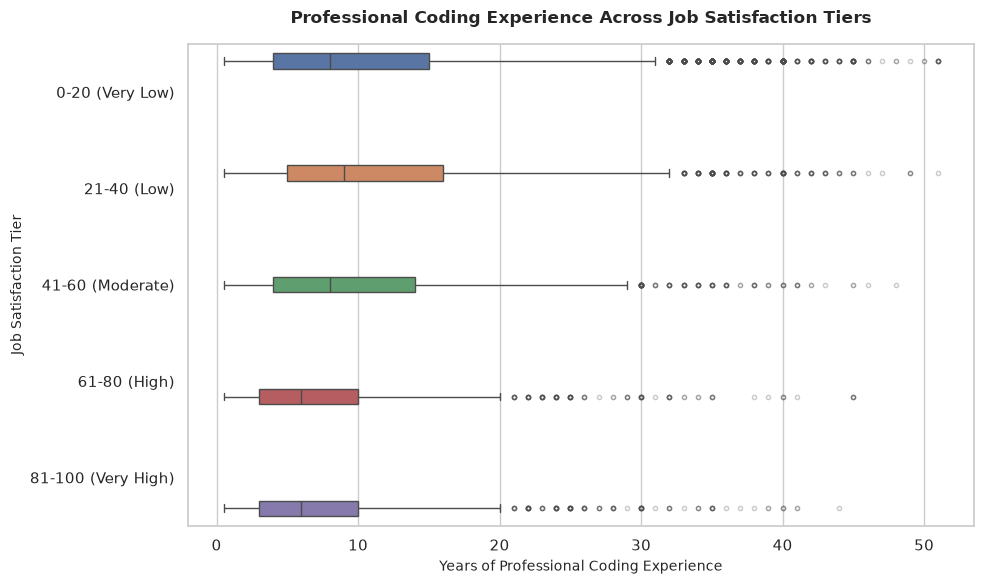

In [46]:
# Query YearsCodePro and JobSatPoints_6
query = """
SELECT YearsCodePro, JobSatPoints_6
FROM main
WHERE YearsCodePro IS NOT NULL
  AND JobSatPoints_6 IS NOT NULL
"""
df_exp_sat = pd.read_sql_query(query, conn)

# Clean numeric values in YearsCodePro
df_exp_sat["YearsCodePro_Num"] = (
    df_exp_sat["YearsCodePro"]
    .str.replace("Less than 1 year", "0.5")
    .str.replace("More than 50 years", "51")
)
df_exp_sat["YearsCodePro_Num"] = pd.to_numeric(
    df_exp_sat["YearsCodePro_Num"], errors="coerce"
)

# Bin 0-100 rating scale into 5 equal satisfaction tiers
sat_labels = [
    "0-20 (Very Low)",
    "21-40 (Low)",
    "41-60 (Moderate)",
    "61-80 (High)",
    "81-100 (Very High)",
]
df_exp_sat["Sat_Tier"] = pd.cut(
    df_exp_sat["JobSatPoints_6"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=sat_labels,
    include_lowest=True,
)

# Drop missing values
df_exp_sat = df_exp_sat.dropna(
    subset=["YearsCodePro_Num", "Sat_Tier"]
).copy()

plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=df_exp_sat,
    x="YearsCodePro_Num",
    y="Sat_Tier",
    order=sat_labels,
    hue="Sat_Tier",
    legend=False,
    flierprops=dict(marker="o", color="red", alpha=0.3, markersize=3),
)

plt.title(
    "Professional Coding Experience Across Job Satisfaction Tiers",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Years of Professional Coding Experience", fontsize=10)
plt.ylabel("Job Satisfaction Tier", fontsize=10)

plt.tight_layout()
plt.show()

**Identical Medians:** Across every tier from 0–20 (Very Low) to 81–100 (Very High), the median professional coding experience sits right around 6 to 8 years.

**Uniform Interquartile Range (IQR):** The core 50% of respondents in each group spans almost the exact same range (roughly 3–4 years at the 25th percentile up to 10–15 years at the 75th percentile).

**Experience Does Not Dictate Satisfaction:** Seniority and years of professional experience have virtually no correlation with job satisfaction—developers at ~5–10 years of experience dominate both the most dissatisfied and the most satisfied cohorts equally.

**Whisker & Outlier Tail:** Lower satisfaction tiers show slightly longer upper whiskers (stretching to ~30 years) and a higher density of 30+ year outliers, but the central tendencies remain virtually identical.

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [47]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
